# 🌦️ Prévision Météorologique avec LSTM — Jena Climate 2009–2016
**Objectif :** Prédire la température (T) à partir des séries temporelles climatiques.

**Pipeline :**
1. Chargement & exploration
2. Nettoyage & preprocessing
3. Feature engineering
4. Séquençage pour LSTM
5. Modélisation (Stacked LSTM + Attention)
6. Évaluation & visualisation

## 0. Imports & configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Chargement des données

In [4]:
# Chargement
df = pd.read_csv('/content/jena_climate_2009_2016.csv')

print(f'Shape: {df.shape}')
print(f'Colonnes: {list(df.columns)}')
df.head()

Shape: (420551, 15)
Colonnes: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [5]:
# Infos générales
df.info()
print('\nValeurs manquantes:')
print(df.isnull().sum())
print('\nStatistiques descriptives:')
df.describe().round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB

Valeurs manquantes:
Date Time      

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000
mean,989.213,9.450,283.493,4.956,76.008,13.576,9.534,4.042,6.022,9.640,1216.063,1.702,3.057,174.744
std,8.358,8.423,8.504,6.731,16.476,7.739,4.184,4.897,2.656,4.235,39.975,65.447,69.017,86.682
min,913.600,-23.010,250.600,-25.010,12.950,0.950,0.790,0.000,0.500,0.800,1059.450,-9999.000,-9999.000,0.000
25%,984.200,3.360,277.430,0.240,65.210,7.780,6.210,0.870,3.920,6.290,1187.490,0.990,1.760,124.900
50%,989.580,9.420,283.470,5.220,79.300,11.820,8.860,2.190,5.590,8.960,1213.790,1.760,2.960,198.100
75%,994.720,15.470,289.530,10.070,89.400,17.600,12.350,5.300,7.800,12.490,1242.770,2.860,4.740,234.100
max,1015.350,37.280,311.340,23.110,100.000,63.770,28.320,46.010,18.130,28.820,1393.540,28.490,23.500,360.000


## 2. Nettoyage & Preprocessing

In [6]:
# Conversion de la colonne Date Time
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time').sort_index()

# Renommer pour commodité
df.columns = [c.strip().replace(' ', '_').replace('(', '').replace(')', '')
              .replace('/', '_per_') for c in df.columns]

# Correction de la vitesse du vent négatif (erreurs capteurs)
df['wv_m_per_s'] = df['wv_m_per_s'].clip(lower=0)
df['max._wv_m_per_s'] = df['max._wv_m_per_s'].clip(lower=0)

# Suppression de la colonne wd_deg si problématique (optionnel)
# La direction du vent en degrés est circulaire → on la convertit
wv = df['wv_m_per_s']
wd_rad = df['wd_deg'] * np.pi / 180  # conversion en radians
df['Wx'] = wv * np.cos(wd_rad)  # composante X du vent
df['Wy'] = wv * np.sin(wd_rad)  # composante Y du vent

max_wv = df['max._wv_m_per_s']
df['max_Wx'] = max_wv * np.cos(wd_rad)
df['max_Wy'] = max_wv * np.sin(wd_rad)

# Supprimer les colonnes de vent en degrés (remplacées par vecteurs)
df.drop(columns=['wd_deg', 'wv_m_per_s', 'max._wv_m_per_s'], inplace=True)

print(f'Shape après nettoyage: {df.shape}')
df.head()

Shape après nettoyage: (420551, 15)


,p_mbar,T_degC,Tpot_K,Tdew_degC,rh_%,VPmax_mbar,VPact_mbar,VPdef_mbar,sh_g_per_kg,H2OC_mmol_per_mol,rho_g_per_m**3,Wx,Wy,max_Wx,max_Wy
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,-0.911955,0.478787,-1.549439,0.813474
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,-0.518797,0.499249,-1.080827,1.040103
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,-0.187962,0.027756,-0.623242,0.092032
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,-0.323359,-0.105066,-0.475528,-0.154508
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,-0.264351,-0.180328,-0.520442,-0.355021


## 3. Feature Engineering temporel

In [7]:
# Features cycliques temporelles (encodage sinus/cosinus)
timestamp_s = df.index.map(pd.Timestamp.timestamp)

# Cycle journalier (24h)
day_s   = 24 * 60 * 60
# Cycle annuel (365.25 jours)
year_s  = 365.25 * day_s

df['Day_sin']  = np.sin(timestamp_s * (2 * np.pi / day_s))
df['Day_cos']  = np.cos(timestamp_s * (2 * np.pi / day_s))
df['Year_sin'] = np.sin(timestamp_s * (2 * np.pi / year_s))
df['Year_cos'] = np.cos(timestamp_s * (2 * np.pi / year_s))

print('Features temporelles ajoutées.')
print(f'Shape finale: {df.shape}')
df.head(3)

Features temporelles ajoutées.
Shape finale: (420551, 19)


,p_mbar,T_degC,Tpot_K,Tdew_degC,rh_%,VPmax_mbar,VPact_mbar,VPdef_mbar,sh_g_per_kg,H2OC_mmol_per_mol,rho_g_per_m**3,Wx,Wy,max_Wx,max_Wy,Day_sin,Day_cos,Year_sin,Year_cos
Date Time,,,,,,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,-0.911955,0.478787,-1.549439,0.813474,0.043619,0.999048,0.004420,0.999990
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,-0.518797,0.499249,-1.080827,1.040103,0.087156,0.996195,0.004540,0.999990
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,-0.187962,0.027756,-0.623242,0.092032,0.130526,0.991445,0.004659,0.999989


In [8]:
# Sous-échantillonnage : garder 1 mesure par heure (données toutes les 10 min)
# Cela réduit le bruit et accélère l'entraînement
df = df[::6]  # 1 toutes les 6 × 10min = 1 par heure
print(f'Shape après sous-échantillonnage horaire: {df.shape}')

Shape après sous-échantillonnage horaire: (70092, 19)


## 4. Visualisation exploratoire

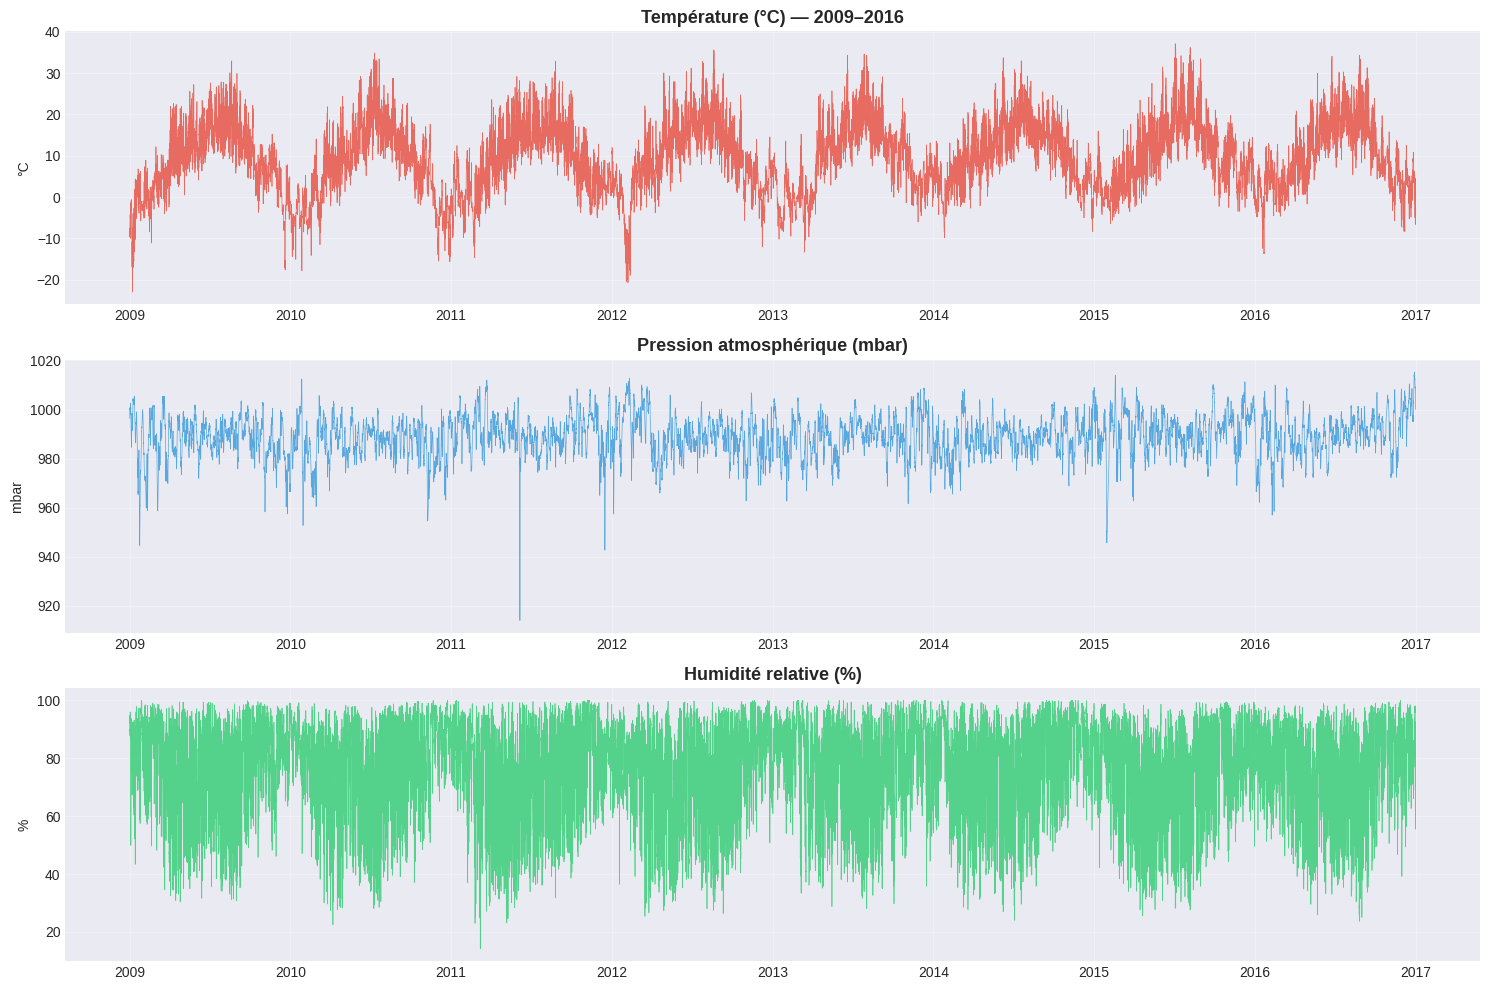

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Température sur toute la période
axes[0].plot(df.index, df['T_degC'], color='#e74c3c', linewidth=0.5, alpha=0.8)
axes[0].set_title('Température (°C) — 2009–2016', fontsize=13, fontweight='bold')
axes[0].set_ylabel('°C')
axes[0].grid(True, alpha=0.3)

# Pression atmosphérique
axes[1].plot(df.index, df['p_mbar'], color='#3498db', linewidth=0.5, alpha=0.8)
axes[1].set_title('Pression atmosphérique (mbar)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('mbar')
axes[1].grid(True, alpha=0.3)

# Humidité relative
axes[2].plot(df.index, df['rh_%'], color='#2ecc71', linewidth=0.5, alpha=0.8)
axes[2].set_title('Humidité relative (%)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('%')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

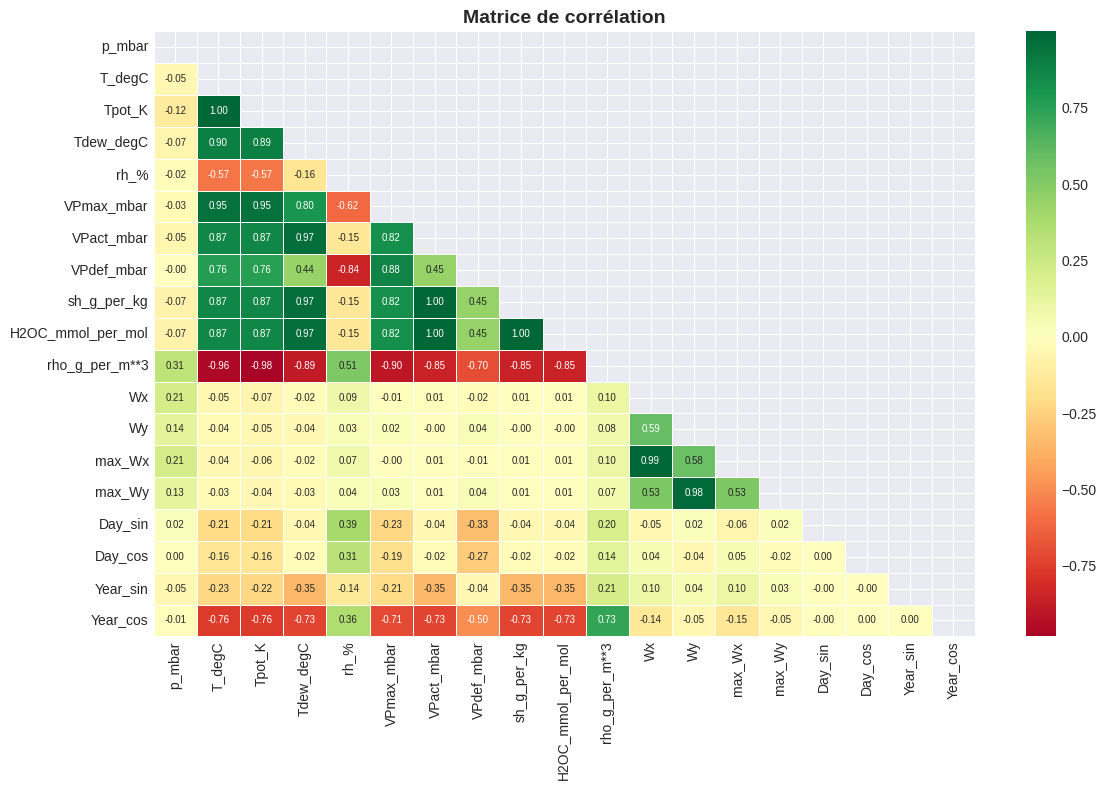

In [10]:
# Heatmap des corrélations
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Préparation des données pour LSTM

In [11]:
# ==================================================
#  PARAMÈTRES CLÉS
# ==================================================
TARGET       = 'T_degC'         # Variable cible
LOOKBACK     = 24 * 7           # Fenêtre d'entrée : 7 jours d'historique horaire
FORECAST_H   = 24               # Horizon de prédiction : 24h (1 jour)
BATCH_SIZE   = 256
EPOCHS       = 100
LEARNING_RATE = 1e-3

# Split chronologique : 70% train / 15% val / 15% test
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f'Train : {train_df.shape} | Val : {val_df.shape} | Test : {test_df.shape}')

Train : (49064, 19) | Val : (10514, 19) | Test : (10514, 19)


In [12]:
# Normalisation (fit uniquement sur train → évite data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

# Scaler spécifique pour la cible seule (pour l'inversion)
target_idx = df.columns.get_loc(TARGET)
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaler_target.fit(train_df[[TARGET]])

print(f'Indice de la cible ({TARGET}): {target_idx}')

Indice de la cible (T_degC): 1


In [13]:
def create_sequences(data, target_idx, lookback, forecast_horizon):
    """
    Crée des séquences X (input) et y (cible future) pour LSTM.
    X : (samples, lookback, features)
    y : (samples,) — valeur de la cible à t + forecast_horizon
    """
    X, y = [], []
    for i in range(lookback, len(data) - forecast_horizon + 1):
        X.append(data[i - lookback:i, :])           # fenêtre passée
        y.append(data[i + forecast_horizon - 1, target_idx])  # valeur future
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_train, y_train = create_sequences(train_scaled, target_idx, LOOKBACK, FORECAST_H)
X_val,   y_val   = create_sequences(val_scaled,   target_idx, LOOKBACK, FORECAST_H)
X_test,  y_test  = create_sequences(test_scaled,  target_idx, LOOKBACK, FORECAST_H)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}   | y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

X_train: (48873, 168, 19) | y_train: (48873,)
X_val  : (10323, 168, 19)   | y_val  : (10323,)
X_test : (10323, 168, 19)  | y_test : (10323,)


## 6. Architecture LSTM optimisée

In [14]:
def build_lstm_model(input_shape, units_1=128, units_2=64, dropout_rate=0.3):
    """
    Stacked Bidirectional LSTM avec Batch Normalization et Dropout.
    """
    inp = keras.Input(shape=input_shape, name='input')

    # Couche 1 : LSTM bidirectionnel
    x = layers.Bidirectional(
        layers.LSTM(units_1, return_sequences=True, kernel_regularizer=keras.regularizers.l2(1e-4)),
        name='biLSTM_1'
    )(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Couche 2 : LSTM
    x = layers.LSTM(units_2, return_sequences=True,
                    kernel_regularizer=keras.regularizers.l2(1e-4),
                    name='LSTM_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate / 2)(x)

    # Mécanisme d'attention simple
    attention = layers.Dense(1, activation='tanh')(x)          # (batch, time, 1)
    attention = layers.Flatten()(attention)                     # (batch, time)
    attention = layers.Activation('softmax', name='attention_weights')(attention)
    attention = layers.RepeatVector(units_2)(attention)         # (batch, units_2, time)
    attention = layers.Permute([2, 1])(attention)               # (batch, time, units_2)

    # Application de l'attention
    x = layers.Multiply()([x, attention])
    x = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)   # (batch, units_2)

    # Couches denses
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    out = layers.Dense(1, name='output')(x)

    model = keras.Model(inp, out, name='Jena_LSTM_Attention')
    return model


model = build_lstm_model(input_shape=(LOOKBACK, X_train.shape[2]))
model.summary()

Model: "Jena_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 168, 19)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ biLSTM_1            │ (None, 168, 256)  │    151,552 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 168, 256)  │      1,024 │ biLSTM_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 168, 256)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_2 (LSTM)       │ (None, 168, 64)   │     82,176 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 168, 64)   │        256 │ LSTM_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 168, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 168, 1)    │         65 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 168)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 168)       │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 64, 168)   │          0 │ attention_weight… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 168, 64)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 168, 64)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 237,186 (926.51 KB)

 Trainable params: 236,546 (924.01 KB)

 Non-trainable params: 640 (2.50 KB)

In [15]:
# Compilation
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='huber', metrics=['mae'])

# Callbacks
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_lstm_model.keras', monitor='val_loss', save_best_only=True, verbose=0
    )
]

print('Modèle compilé. Prêt à entraîner.')

Modèle compilé. Prêt à entraîner.


## 7. Entraînement

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - loss: 0.0424 - mae: 0.1071 - val_loss: 0.1155 - val_mae: 0.4120 - learning_rate: 0.0010
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - loss: 0.0255 - mae: 0.0723 - val_loss: 0.0306 - val_mae: 0.1424 - learning_rate: 0.0010
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - loss: 0.0180 - mae: 0.0659 - val_loss: 0.0152 - val_mae: 0.0622 - learning_rate: 0.0010
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - loss: 0.0131 - mae: 0.0608 - val_loss: 0.0114 - val_mae: 0.0607 - learning_rate: 0.0010
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - loss: 0.0100 - mae: 0.0575 - val_loss: 0.0086 - val_mae: 0.0544 - learning_rate: 0.0010
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - loss: 0.0080 - mae: 0.0556 - val_loss: 0.0063 - val_mae: 0.0453 - learning_rate: 0.0010
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 0.0065 - mae: 0.0532 - val_loss: 0.0053 - val_mae: 0.0447 - learnin

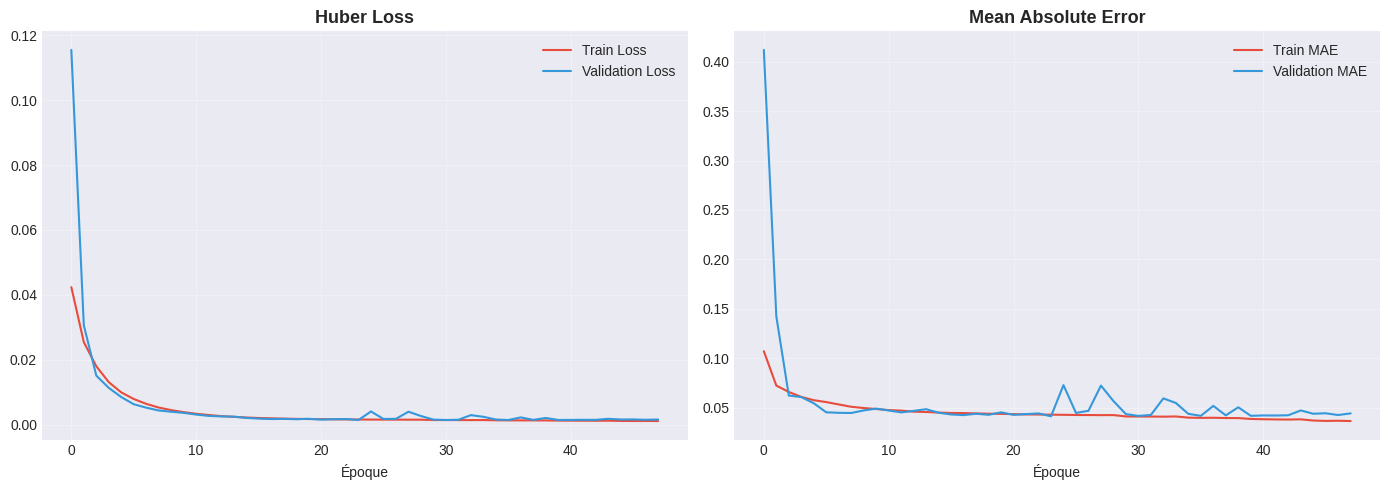

In [17]:
# Courbes de perte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',      color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#3498db')
axes[0].set_title('Huber Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE',      color='#e74c3c')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#3498db')
axes[1].set_title('Mean Absolute Error', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Évaluation sur le jeu de test

In [18]:
# Prédictions
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

# Inversion de la normalisation
y_pred = scaler_target.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Métriques
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100

print('=' * 45)
print('       RÉSULTATS SUR LE JEU DE TEST')
print('=' * 45)
print(f'  MAE  : {mae:.3f} °C')
print(f'  RMSE : {rmse:.3f} °C')
print(f'  MAPE : {mape:.2f} %')
print(f'  R²   : {r2:.4f}')
print('=' * 45)

       RÉSULTATS SUR LE JEU DE TEST
  MAE  : 2.458 °C
  RMSE : 3.089 °C
  MAPE : 282513.34 %
  R²   : 0.8447


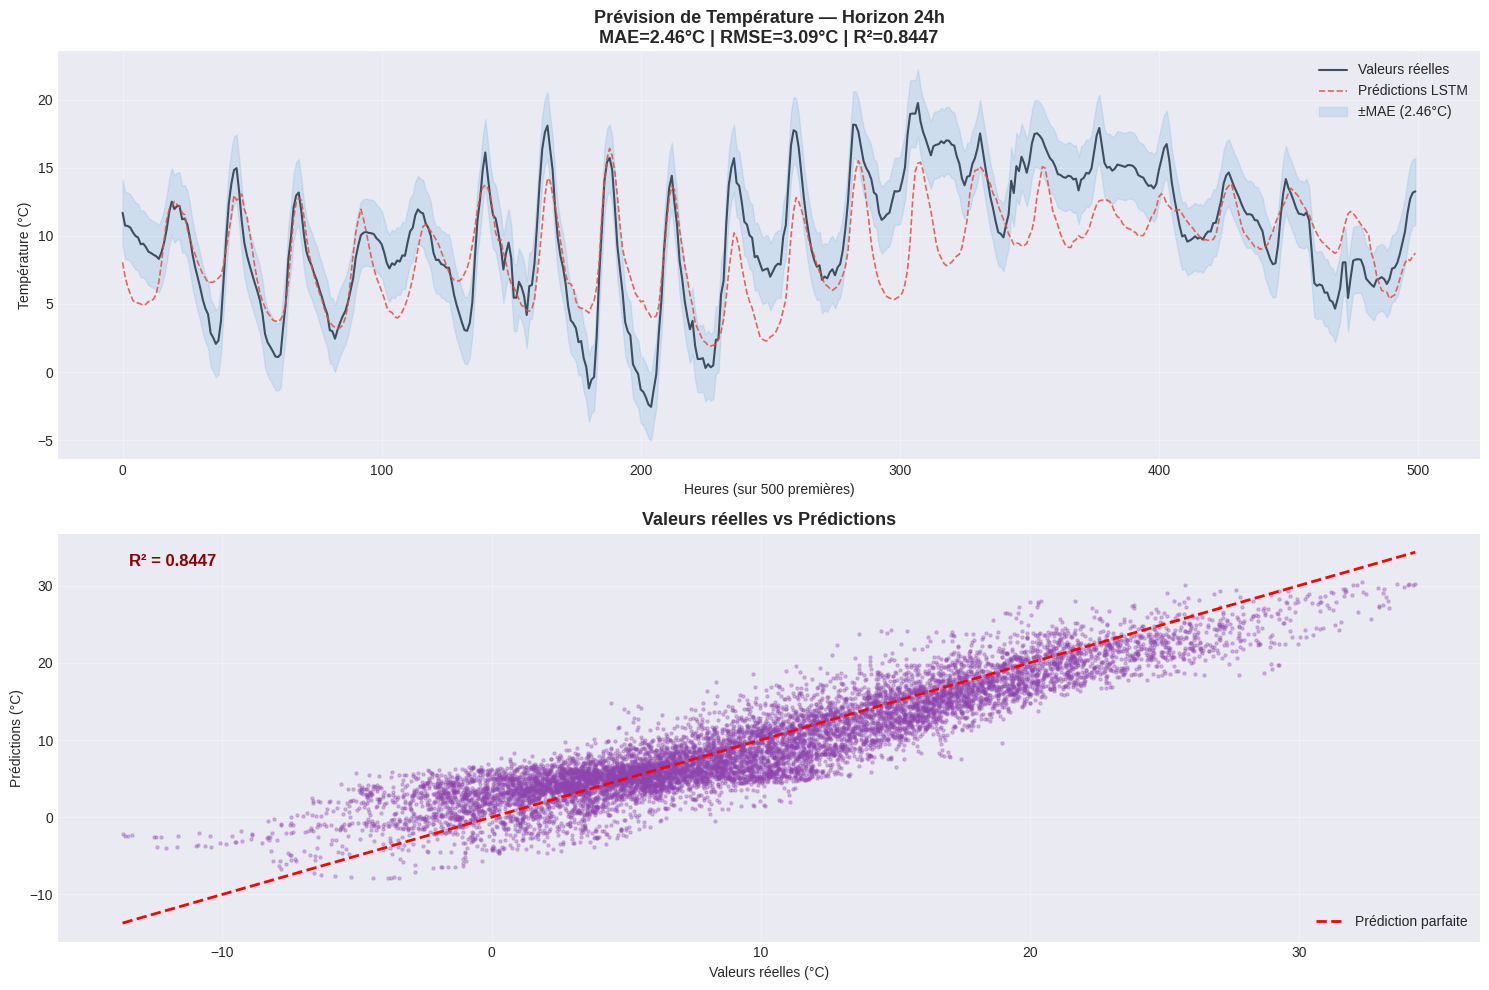

In [19]:
# Visualisation : Prédictions vs Réalité (500 premiers points)
N_SHOW = 500

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Graphe temporel
axes[0].plot(y_true[:N_SHOW], label='Valeurs réelles',   color='#2c3e50', linewidth=1.5, alpha=0.9)
axes[0].plot(y_pred[:N_SHOW], label='Prédictions LSTM',  color='#e74c3c', linewidth=1.2, alpha=0.85, linestyle='--')
axes[0].fill_between(range(N_SHOW),
                     y_true[:N_SHOW] - mae,
                     y_true[:N_SHOW] + mae,
                     alpha=0.15, color='#3498db', label=f'±MAE ({mae:.2f}°C)')
axes[0].set_title(f'Prévision de Température — Horizon {FORECAST_H}h\n'
                  f'MAE={mae:.2f}°C | RMSE={rmse:.2f}°C | R²={r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Température (°C)')
axes[0].set_xlabel(f'Heures (sur {N_SHOW} premières)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Scatter plot
axes[1].scatter(y_true, y_pred, alpha=0.3, s=5, color='#8e44ad')
min_v, max_v = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Prédiction parfaite')
axes[1].set_title('Valeurs réelles vs Prédictions', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valeurs réelles (°C)')
axes[1].set_ylabel('Prédictions (°C)')
axes[1].text(0.05, 0.92, f'R² = {r2:.4f}', transform=axes[1].transAxes,
             fontsize=12, color='darkred', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

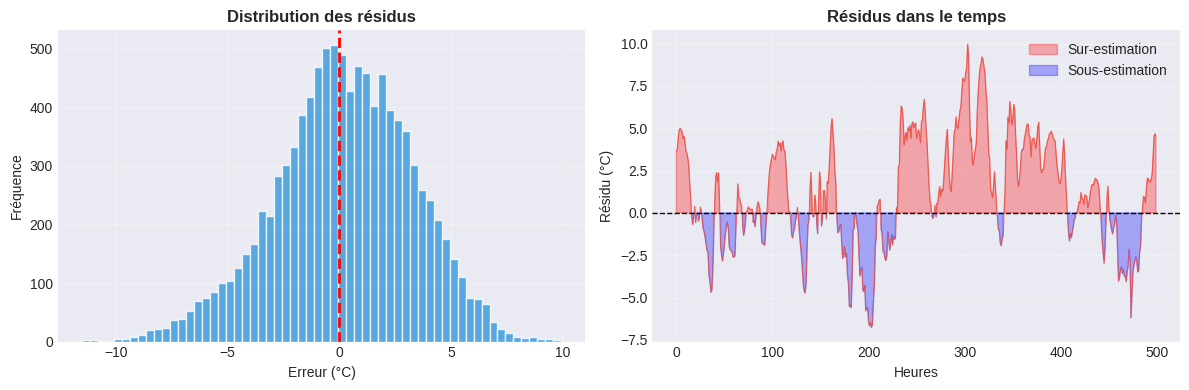

In [20]:
# Distribution des erreurs de résidu
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=60, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution des résidus', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Erreur (°C)')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, alpha=0.3)

axes[1].plot(residuals[:500], color='#e74c3c', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(range(min(500, len(residuals))), residuals[:500], 0,
                     where=residuals[:500] > 0, alpha=0.3, color='red',    label='Sur-estimation')
axes[1].fill_between(range(min(500, len(residuals))), residuals[:500], 0,
                     where=residuals[:500] < 0, alpha=0.3, color='blue',   label='Sous-estimation')
axes[1].set_title('Résidus dans le temps', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Heures')
axes[1].set_ylabel('Résidu (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Prévision multi-horizon (baseline de comparaison)

In [21]:
# Baseline naïve : prédire T(t) = T(t-24h)
# Pour le test, on prend la valeur 24h avant
y_baseline = y_true  # décalage de 24h déjà intégré dans la construction des séquences
# Calcul du baseline (persistence model)
n_test = len(test_scaled)
lookback_offset = LOOKBACK + FORECAST_H - 1

target_raw = scaler_target.inverse_transform(
    test_scaled[:, target_idx].reshape(-1, 1)
).flatten()

# Persistence : valeur 24h avant dans la série de test
persistence_start = lookback_offset - FORECAST_H
persistence_end   = lookback_offset - FORECAST_H + len(y_true)
y_persist = target_raw[persistence_start:persistence_end]

# Aligner les longueurs
min_len = min(len(y_true), len(y_persist))
mae_persist  = mean_absolute_error(y_true[:min_len], y_persist[:min_len])
rmse_persist = np.sqrt(mean_squared_error(y_true[:min_len], y_persist[:min_len]))

print('\n📊 Comparaison des modèles')
print('-' * 40)
print(f'  Persistence Model — MAE: {mae_persist:.3f}°C | RMSE: {rmse_persist:.3f}°C')
print(f'  LSTM Attention    — MAE: {mae:.3f}°C | RMSE: {rmse:.3f}°C')
improvement_mae = (1 - mae / mae_persist) * 100
print(f'  Amélioration MAE  : {improvement_mae:.1f}%')
print('-' * 40)


📊 Comparaison des modèles
----------------------------------------
  Persistence Model — MAE: 2.502°C | RMSE: 3.253°C
  LSTM Attention    — MAE: 2.458°C | RMSE: 3.089°C
  Amélioration MAE  : 1.8%
----------------------------------------


## 10. Sauvegarde du modèle

In [22]:
# Sauvegarde finale
model.save('jena_lstm_final.keras')

import joblib
joblib.dump(scaler,        'scaler_all.pkl')
joblib.dump(scaler_target, 'scaler_target.pkl')

print('✅ Modèle et scalers sauvegardés.')
print()
print('Fichiers générés :')
print('  • jena_lstm_final.keras')
print('  • scaler_all.pkl')
print('  • scaler_target.pkl')
print('  • training_curves.png')
print('  • predictions_vs_actual.png')
print('  • residuals.png')

✅ Modèle et scalers sauvegardés.

Fichiers générés :
  • jena_lstm_final.keras
  • scaler_all.pkl
  • scaler_target.pkl
  • training_curves.png
  • predictions_vs_actual.png
  • residuals.png


## 📋 Résumé du projet

| Étape | Détail |
|---|---|
| **Dataset** | Jena Climate 2009–2016 (420 550 mesures → ~70 000 après ré-échantillonnage horaire) |
| **Cible** | Température `T (degC)` à +24h |
| **Features** | 14 variables météo + vent vectoriel (Wx, Wy) + encodage cyclique jour/an |
| **Architecture** | BiLSTM(128) → LSTM(64) → Attention → Dense(32) → Dense(1) |
| **Régularisation** | Dropout, Batch Normalization, L2, Huber Loss |
| **Optimiseur** | Adam + ReduceLROnPlateau + EarlyStopping |
| **Fenêtre** | 168h (7 jours) → prédiction à 24h |

### Points clés du design :
- **Pas de data leakage** : scaler fitté uniquement sur train
- **Split chronologique** : 70/15/15 sans shuffle
- **Vent vectoriel** : direction convertie en composantes (Wx, Wy) → évite la circularité
- **Encodage cyclique** : sin/cos pour heure et saison → le modèle comprend la périodicité
- **Huber Loss** : robuste aux outliers vs MSE
- **Mécanisme d'attention** : le modèle pondère les pas de temps importants